In [1]:
import cirq
from cirq.contrib.svg import SVGCircuit
import sys
from pprint import pprint
import warnings

sys.path.append("../../")
import resource_estimation as res

_PRETTY = False  # I don't think the SVG circuits are pretty, but this is an option
cast_circuit = lambda circuit: (
    SVGCircuit(circuit) if _PRETTY else circuit
)  # A cirq contribution's version of 'pretty'

# Looking Closer at Distillation Primitives

In [2]:
# Architectures that currently support Distillation
ssm = res.ftqc.architecture.DefaultMovement(cultivation_repetition=5, distillation_repetition=1)
dsm = res.ftqc.architecture.DualSpeciesMovement(cultivation_repetition=5, distillation_repetition=1)
mzo = res.ftqc.architecture.MeasureZonesOnly(cultivation_repetition=5, distillation_repetition=1)

arc = dsm  # Change this to experiment with different architectures
estimator = res.ftqc.estimate.ResourceEstimator(arc)

t_example_op = res.ftqc.lattice_surgery_primitives.Distil("T").on(*cirq.LineQubit.range(31))
toff_example_op = res.ftqc.lattice_surgery_primitives.Distil("Toffoli").on(
    *cirq.LineQubit.range(23)
)
print(t_example_op.gate)
print(toff_example_op.gate)

DISTIL(T)
DISTIL(Toffoli)


In [3]:
# Wait...They take the same time? Curious. Let's look at the circuits
t_time = arc.op_time(t_example_op)
toff_time = arc.op_time(toff_example_op)
print(f"T Distil Time.......{t_time:.5e}")
print(f"Toff Distil Time....{toff_time:.5e}")

T Distil Time.......9.07960e+04
Toff Distil Time....9.07960e+04


## Source Material
8T to 1CCZ (https://arxiv.org/pdf/1812.01238) and 15T to 1T (https://arxiv.org/pdf/1208.0928)

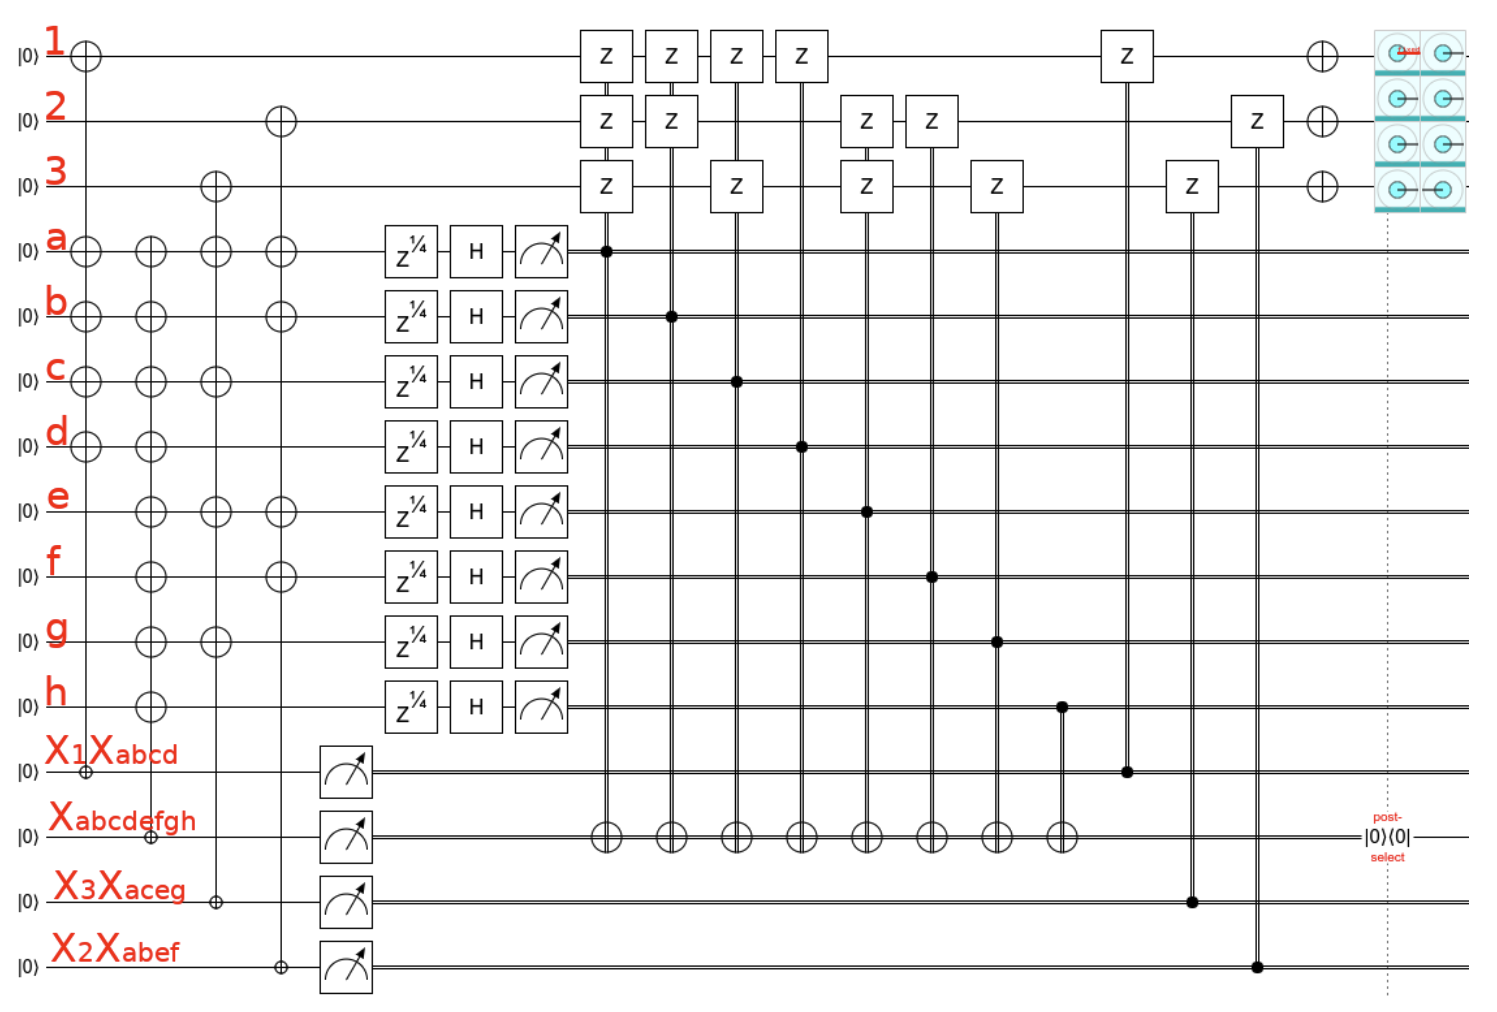

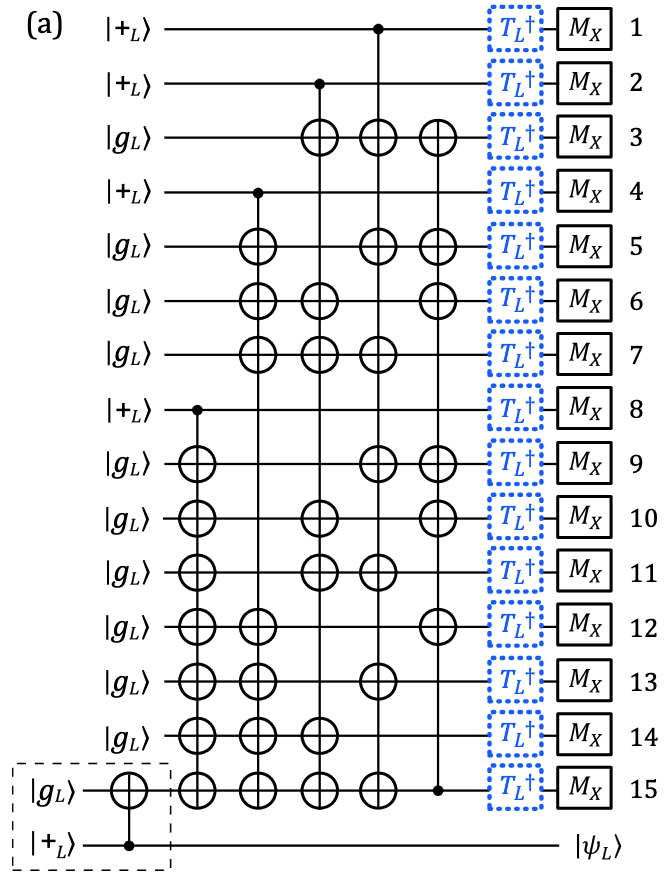

## Our Implementations
These implementations include one T Cultivation factory per logical T gate in the input circuit

In [4]:
cast_circuit(res.ftqc.distil.ccz_8_to_1())

┌───┐       ┌──┐   ┌───┐   ┌───┐   ┌────┐       ┌──┐   ┌──┐   ┌────┐
(0, 0): ───R─────────────H────@──────@────@──────@───────@────────────────────────────────────────────────────────────H───M('q(11)')───
                              │      │    │      │       │
(0, 1): ───R─────────────H────┼──────┼────┼@─────┼@──────┼@──────@───────@────@──────@──────@─────────────────────────H───M('q(12)')───
                              │      │    ││     ││      ││      │       │    │      │      │
(0, 2): ───R─────────────H────┼@─────┼────┼┼─────┼┼@─────┼┼──────┼@──────┼────┼@─────┼──────┼@────────────────────────H───M('q(13)')───
                              ││     │    ││     │││     ││      ││      │    ││     │      ││
(0, 3): ───R─────────────H────┼┼@────┼────┼┼─────┼┼┼─────┼┼@─────┼┼@─────┼────┼┼─────┼@─────┼┼@───────────────────────H───M('q(14)')───
                              │││    │    ││     │││     │││     │││     │    ││     ││     │││
(1, 0): ───CULT(0.785)────────┼┼┼────┼────┼┼─────┼┼┼─────┼┼┼─────┼┼┼X────┼────┼┼─────┼┼─────┼┼┼─────────M('C0')────────────────────────
                              │││    │    ││     │││     │││     ││││    │    ││     ││     │││
(1, 1): ───R──────────────────┼┼┼────X────┼X─────┼┼X─────┼┼X─────┼┼┼@────┼────┼┼─────┼┼─────┼┼┼───────────────────S───H───M('q(3)')────
                              │││         │      ││      ││      │││     │    ││     ││     │││
(1, 2): ───R──────────────────┼┼┼─────────┼──────┼┼──────┼┼──────┼┼┼─────X────┼X─────┼X─────┼┼┼@──────────────────S───H───M('q(7)')────
                              │││         │      ││      ││      │││          │      │      ││││
(1, 3): ───CULT(0.785)────────┼┼┼─────────┼──────┼┼──────┼┼──────┼┼┼──────────┼──────┼──────┼┼┼X────────M('C4')────────────────────────
                              │││         │      ││      ││      │││          │      │      │││
(2, 0): ───CULT(0.785)────────┼┼┼─────────┼──────┼┼──────┼┼──────┼┼┼─────X────┼──────┼──────┼┼┼─────────M('C1')────────────────────────
                              │││         │      ││      ││      │││     │    │      │      │││
(2, 1): ───R──────────────────┼┼┼─────────X──────┼X──────┼┼──────┼┼X─────@────┼──────┼──────┼┼┼───────────────────S───H───M('q(4)')────
                              │││                │       ││      ││           │      │      │││
(2, 2): ───R──────────────────┼┼┼────────────────┼───────┼┼──────┼┼───────────X──────┼──────┼┼X─────@─────────────S───H───M('q(8)')────
                              │││                │       ││      ││                  │      ││      │
(2, 3): ───CULT(0.785)────────┼┼┼────────────────┼───────┼┼──────┼┼──────────────────┼──────┼┼──────X───M('C5')────────────────────────
                              │││                │       ││      ││                  │      ││
(3, 0): ───CULT(0.785)────────┼┼┼────────────────┼───────┼┼──────┼┼──────X───────────┼──────┼┼──────────M('C2')────────────────────────
                              │││                │       ││      ││      │           │      ││
(3, 1): ───R──────────────────┼┼┼────────────────X───────┼X──────┼X──────@───────────┼──────┼┼────────────────────S───H───M('q(5)')────
                              │││                        │       │                   │      ││
(3, 2): ───R──────────────────┼┼┼────────────────────────┼───────┼───────────────────X──────┼X──────@─────────────S───H───M('q(9)')────
                              │││                        │       │                          │       │
(3, 3): ───CULT(0.785)────────┼┼┼────────────────────────┼───────┼──────────────────────────┼───────X───M('C6')────────────────────────
                              │││                        │       │                          │
(4, 0): ───CULT(0.785)────────┼┼┼────────────────────────┼───────┼───────X──────────────────┼───────────M('C3')────────────────────────
                              │││                        │       │       │                  │
(4, 1): ───R─────────

In [5]:
cast_circuit(res.ftqc.distil.distil_15_to_1())

┌──┐   ┌──┐   ┌────┐   ┌───┐   ┌──┐   ┌─────┐   ┌───┐   ┌───┐   ┌──┐       ┌──┐
(0, 0): ───CULT(0.785)────────────────────────────────────────────────────────────────@────────────────────────────M('C0')─────────────────────────
                                                                                      │
(0, 1): ───R─────────────H─────@─────@─────────@───────@─────@──────────@─────@───────X───────────────────────────────────────S───H───M('q(0)')────
                               │     │         │       │     │          │     │
(0, 2): ───R───────────────────┼─────┼─────────┼─────X─┼─────X──────────┼─────┼───────────────X─────X─────────────────────────S───H───M('q(8)')────
                               │     │         │     │ │                │     │               │     │
(0, 3): ───CULT(0.785)─────────┼─────┼─────────┼─────┼─┼────────────────┼─────┼───────────────┼─────@──────────────M('C8')─────────────────────────
                               │     │         │     │ │                │     │               │
(1, 0): ───CULT(0.785)─────────┼─────┼─────────┼─────┼─┼────────────────┼─────┼───────────────┼@───────────────────M('C1')─────────────────────────
                               │     │         │     │ │                │     │               ││
(1, 1): ───R─────────────H────@┼─────┼@───────@┼─────┼@┼──────@────────@┼─────┼───────@───────┼X──────────────────────────────S───H───M('q(1)')────
                              ││     ││       ││     │││      │        ││     │       │       │
(1, 2): ───R──────────────────┼┼─────┼┼───────┼┼─────┼X┼─────X┼────────┼┼─────┼───────┼X──────┼X──────────────────────────────S───H───M('q(9)')────
                              ││     ││       ││     │ │     ││        ││     │       ││      ││
(1, 3): ───CULT(0.785)────────┼┼─────┼┼───────┼┼─────┼─┼─────┼┼────────┼┼─────┼───────┼┼──────┼@───────────────────M('C9')─────────────────────────
                              ││     ││       ││     │ │     ││        ││     │       ││      │
(2, 0): ───CULT(0.785)────────┼┼─────┼┼───────┼┼─────┼─┼─────┼┼────────┼┼─────┼───────┼┼──────┼────────────────@───M('C2')─────────────────────────
                              ││     ││       ││     │ │     ││        ││     │       ││      │                │
(2, 1): ───R──────────────────┼┼─────┼┼───────┼┼─────┼─┼─────┼X────────┼┼─────X───────┼┼──────┼──────────X─────X──────────────S───H───M('q(2)')────
                              ││     ││       ││     │ │     │         ││             ││      │          │
(2, 2): ───R──────────────────X┼─────X┼───────┼┼─────┼─┼─────┼───────X─┼┼─────X───────┼┼──────┼──────────┼────────────────────S───H───M('q(10)')───
                               │      │       ││     │ │     │       │ ││     │       ││      │          │
(2, 3): ───CULT(0.785)─────────┼──────┼───────┼┼─────┼─┼─────┼───────┼─┼┼─────@───────┼┼──────┼──────────┼─────────M('C10')────────────────────────
                               │      │       ││     │ │     │       │ ││             ││      │          │
(3, 0): ───CULT(0.785)─────────┼──────┼───────┼┼─────┼─┼─────┼───────┼─┼┼─────────────┼┼@─────┼──────────┼─────────M('C3')─────────────────────────
                               │      │       ││     │ │     │       │ ││             │││     │          │
(3, 1): ───R─────────────H────@┼─────@┼──────@┼┼─────┼@┼─────┼@──────┼@┼┼───────@─────┼┼X─────┼──────────┼────────────────────S───H───M('q(3)')────
                              ││     ││      │││     │││     ││      ││││       │     ││      │          │
(3, 2): ───R──────────────────┼┼─────X┼──────┼┼┼─────┼┼┼─────┼┼─────X┼┼┼┼──────X┼─────┼┼X─────┼──────────┼────────────────────S───H───M('q(11)')───
                              ││      │      │││     │││     ││     │││││      ││     │││     │          │
(3, 3): ───CULT(0.785)────────┼┼──────┼──────┼┼┼─────┼┼┼─────┼┼─────┼┼┼┼┼──────┼┼─────┼┼@─────┼──────────┼─────────M('C11')────────────────────────
                              ││      │      

## Assessing the Critical Path

In [6]:
# Circuits have different numbers of CNOT moments, but the critical paths are the same
# The path of the T injection (Cult; CNOT; S; H; M) dominates the paths with 12 logical CNOTs on the critical path
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    pprint(
        [
            "Measure" if type(op.gate) == cirq.MeasurementGate else str(op.gate)
            for op in estimator.critical_path(res.ftqc.distil.distil_15_to_1())
        ]
    )
    pprint(
        [
            "Measure" if type(op.gate) == cirq.MeasurementGate else str(op.gate)
            for op in estimator.critical_path(res.ftqc.distil.ccz_8_to_1())
        ]
    )

['CULT(0.785)', 'CNOT', 'S', 'H', 'Measure']
['CULT(0.785)', 'CNOT', 'S', 'H', 'Measure']
